In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from tqdm import tqdm

In [5]:
# Config
YOLO_MODEL_PATH  = "../models/yolov8s_rice_leaf.pt"
SOURCE_DIR       = "../data/augmented"   # Ảnh gốc đã augment (có class folders)
CROPPED_DIR      = "../data/cropped"     # Output: ảnh đã crop

CONF_THRESHOLD   = 0.3    # Confidence tối thiểu
PADDING          = 10     # Pixel padding xung quanh box (tránh cắt sát)
CROP_SIZE        = 224    # Resize crop về kích thước MobileNet
FALLBACK_RESIZE  = True   # Nếu YOLO không detect → dùng ảnh gốc resize thay vì bỏ

CLASS_NAMES = [
    "bacterial_blight",
    "barrow_brown_leaf_spot",
    "brown_spot",
    "healthy",
    "leaf_blast",
    "leaf_scald",
    "leaf_smut",
    # "neck_blast",
    "rice_hispa",
    "sheath_blight",
    # "tungro"
]

In [6]:
# 1. Load YOLO
yolo = YOLO(YOLO_MODEL_PATH)
print(f" Loaded YOLO model: {YOLO_MODEL_PATH}")

 Loaded YOLO model: ../models/yolov8s_rice_leaf.pt


In [7]:
# 2. Hàm crop
def crop_largest_detection(img_bgr, results, padding=10):
    """
    Crop bbox lớn nhất từ kết quả YOLO.
    Returns: cropped image (BGR) hoặc None nếu không detect được.
    """
    h, w = img_bgr.shape[:2]
    boxes = results[0].boxes
    
    if boxes is None or len(boxes) == 0:
        return None
    
    # Lấy box có area lớn nhất
    xyxy = boxes.xyxy.cpu().numpy()  # [N, 4]
    areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
    best_idx = np.argmax(areas)
    
    x1, y1, x2, y2 = xyxy[best_idx].astype(int)
    
    # Thêm padding
    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(w, x2 + padding)
    y2 = min(h, y2 + padding)
    
    crop = img_bgr[y1:y2, x1:x2]
    return crop if crop.size > 0 else None


def process_image(img_path, yolo_model, conf, padding, crop_size, fallback):
    """
    Returns (cropped_img_bgr, status)
    status: 'detected' | 'fallback' | 'error'
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None, 'error'
    
    results = yolo_model.predict(img, conf=conf, verbose=False)
    crop = crop_largest_detection(img, results, padding)
    
    if crop is not None:
        crop = cv2.resize(crop, (crop_size, crop_size))
        return crop, 'detected'
    
    if fallback:
        resized = cv2.resize(img, (crop_size, crop_size))
        return resized, 'fallback'
    
    return None, 'no_detection'

print(" Helper functions defined")

 Helper functions defined


In [8]:
# 3. Crop toàn bộ dataset
stats = {cls: {'detected': 0, 'fallback': 0, 'error': 0} for cls in CLASS_NAMES}

for class_name in CLASS_NAMES:
    src_class_dir = os.path.join(SOURCE_DIR, class_name)
    dst_class_dir = os.path.join(CROPPED_DIR, class_name)
    
    if not os.path.isdir(src_class_dir):
        print(f"  Skipping {class_name} (folder not found)")
        continue
    
    os.makedirs(dst_class_dir, exist_ok=True)
    
    images = [f for f in os.listdir(src_class_dir)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_file in tqdm(images, desc=f"{class_name}", ncols=80):
        src_path = os.path.join(src_class_dir, img_file)
        dst_path = os.path.join(dst_class_dir, img_file)
        
        # Skip nếu đã tồn tại
        if os.path.exists(dst_path):
            stats[class_name]['detected'] += 1
            continue
        
        crop, status = process_image(
            src_path, yolo, CONF_THRESHOLD, PADDING, CROP_SIZE, FALLBACK_RESIZE
        )
        
        if crop is not None:
            cv2.imwrite(dst_path, crop)
        
        stats[class_name][status] += 1

print("\n Cropping done!")

sheath_blight: 100%|████████████████████████| 3201/3201 [10:03<00:00,  5.31it/s]


 Cropping done!


In [9]:
# 4. Thống kê kết quả
print("\n" + "="*75)
print(f"{'CLASS':<25} {'DETECTED':>10} {'FALLBACK':>10} {'ERROR':>10} {'TOTAL':>10}")
print("="*75)

total_det = total_fb = total_err = 0
for cls in CLASS_NAMES:
    d  = stats[cls]['detected']
    fb = stats[cls]['fallback']
    er = stats[cls]['error']
    total_det += d; total_fb += fb; total_err += er
    print(f"{cls:<25} {d:>10} {fb:>10} {er:>10} {d+fb+er:>10}")

print("="*75)
total = total_det + total_fb + total_err
print(f"{'TOTAL':<25} {total_det:>10} {total_fb:>10} {total_err:>10} {total:>10}")
print(f"\nDetection rate  : {total_det/total*100:.1f}%")
print(f"Fallback rate   : {total_fb/total*100:.1f}%")


CLASS                       DETECTED   FALLBACK      ERROR      TOTAL
bacterial_blight                3892        120          0       4012
barrow_brown_leaf_spot          1974         37          0       2011
brown_spot                      5040         59          0       5099
healthy                         3721        387          0       4108
leaf_blast                      4763        234          0       4997
leaf_scald                      2917         92          0       3009
leaf_smut                        307          2          0        309
rice_hispa                      1895        109          0       2004
sheath_blight                   3068        133          0       3201
TOTAL                          27577       1173          0      28750

Detection rate  : 95.9%
Fallback rate   : 4.1%


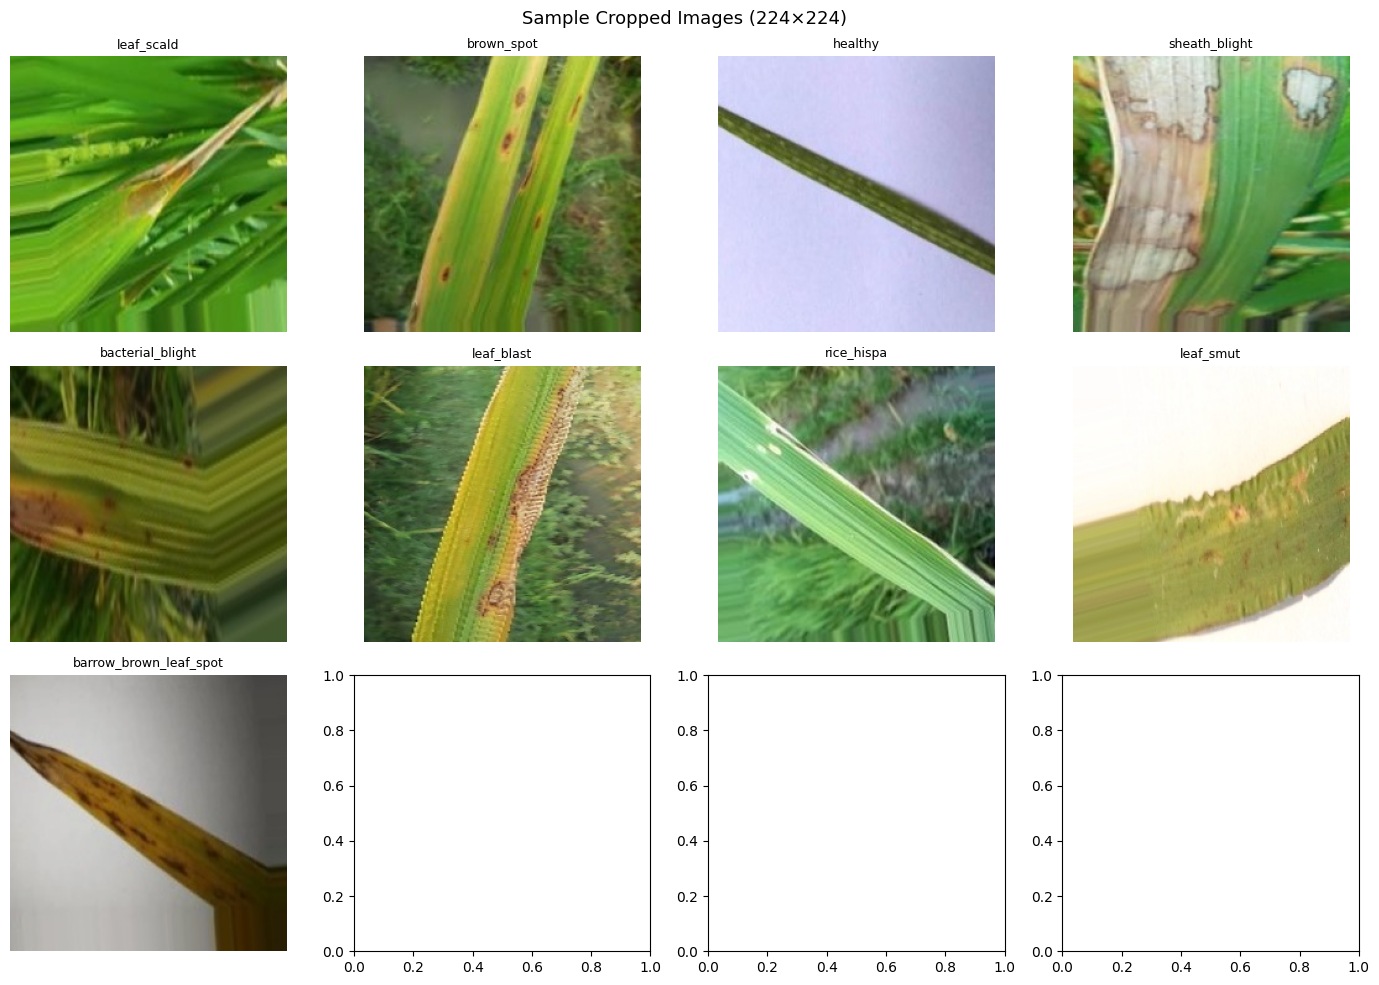

In [10]:
# 5. Visualize 12 ảnh crop mẫu
import random
random.seed(7)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

sample_classes = random.sample(CLASS_NAMES, min(12, len(CLASS_NAMES)))

for ax, cls in zip(axes, sample_classes):
    dst_dir = os.path.join(CROPPED_DIR, cls)
    imgs = [f for f in os.listdir(dst_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not imgs:
        ax.axis('off')
        continue
    
    sample_img = random.choice(imgs)
    img_path = os.path.join(dst_dir, sample_img)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Cropped Images (224×224)', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# 6. Summary
print("="*60)
print("NEXT STEP: Phase 3 - Train MobileNet on Cropped Images")
print("="*60)
print(f"1. Run 02_prepare_data.ipynb với SOURCE_DIR = '../data/cropped'")
print(f"   -> Set USE_AUGMENTED_DATA = False")
print(f"   -> Sửa SOURCE_DIR = '../data/cropped'")
print(f"2. Run 03_train_model.ipynb")
print(f"3. Run 04_evaluate_model.ipynb")
print("="*60)

NEXT STEP: Phase 3 - Train MobileNet on Cropped Images
1. Run 02_prepare_data.ipynb với SOURCE_DIR = '../data/cropped'
   -> Set USE_AUGMENTED_DATA = False
   -> Sửa SOURCE_DIR = '../data/cropped'
2. Run 03_train_model.ipynb
3. Run 04_evaluate_model.ipynb
